In [1]:
import os
import pickle
from typing import List, Dict, Any, Tuple, Optional, Set
import numpy as np
import matplotlib.pyplot as plt

# =========================
#   FUNCIÓN PRINCIPAL
# =========================
def plot_indicadores_from_pkl(folder: str) -> Dict[str, str]:
    """
    Busca .pkl en 'folder' y genera las figuras:
      - fig_2_<base>_Humanos.jpg  (1x3: MOI, SH, PI)
      - fig_3_<base>_Humanos.jpg  (1xN: IBD por parental)
      - fig_2_<base>_Mosquitos.jpg
      - fig_3_<base>_Mosquitos.jpg

    Reglas:
      - MOI: mean y median (IC95%). MISMO color, mean sólido, median punteado.
      - SH: solo mean (IC95%). SIN mediana.
      - PI: solo mean (IC95%). SIN mediana.
      - IBD: mean vs median (IC95%) por parental.

    Retorna:
      dict con nombres de archivo generados.
    """

    # ==== Constantes ====
    METRICS_NON_IBD = ["MOI", "SH", "PI"]
    COLORS = {  # color por indicador
        "MOI": "C0",       # azul
        "SH": "C1",        # naranja
        "PI": "C2",        # verde
    }

    # ==== Descubrir archivos PKL ====
    if not os.path.isdir(folder):
        raise FileNotFoundError(f"No existe la carpeta: {folder}")

    pkl_files = [os.path.join(folder, f) for f in os.listdir(folder) if f.endswith(".pkl")]
    pkl_files.sort()
    if not pkl_files:
        raise FileNotFoundError(f"No se encontraron .pkl en la carpeta: {folder}")

    base = os.path.basename(os.path.normpath(folder))
    out_paths = {
        "fig2_human": f"fig_2_{base}_Humanos.jpg",
        "fig3_human": f"fig_3_{base}_Humanos.jpg",
        "fig2_mosq":  f"fig_2_{base}_Mosquitos.jpg",
        "fig3_mosq":  f"fig_3_{base}_Mosquitos.jpg",
    }

    # ---------- Helpers de IO ----------
    def load_pkl(path: str) -> Dict[str, Any]:
        with open(path, "rb") as f:
            d = pickle.load(f)
        if not isinstance(d, dict):
            raise TypeError(f"{path}: PKL debe contener un dict.")
        return d

    # ---------- Estadísticos ----------
    def stack_runs(series_list: List[np.ndarray]) -> np.ndarray:
        """Apila listas 1D con distinto largo en una matriz (n_runs, T) con NaN padding."""
        T = max(len(s) for s in series_list)
        M = np.full((len(series_list), T), np.nan, dtype=float)
        for i, s in enumerate(series_list):
            M[i, :len(s)] = s
        return M

    def nanmean_ci95(mat: np.ndarray) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
        """Media y banda de IC95% por columna, ignorando NaNs."""
        m = np.nanmean(mat, axis=0)
        s = np.nanstd(mat, axis=0, ddof=1)
        n = np.sum(~np.isnan(mat), axis=0).astype(float)
        se = np.where(n > 1, s / np.sqrt(n), 0.0)
        ci = 1.96 * se
        return m, m - ci, m + ci

    # ---------- Extracción de series ----------
    def extract_series_non_ibd(block: Dict[str, Any], metric: str) -> Optional[List[float]]:
        """Extrae MOI/SH/PI como lista."""
        if metric not in block:
            return None
        s = block[metric]
        return s if isinstance(s, list) else None

    def extract_series_ibd_parental(block: Dict[str, Any], parental: str) -> Optional[List[float]]:
        """Extrae la serie de IBD para un parental específico."""
        ibd = block.get("IBD", {})
        if not isinstance(ibd, dict):
            return None
        s = ibd.get(parental)
        return s if isinstance(s, list) else None

    def list_parentals_for_species(pkl_paths: List[str], species_keys: List[str]) -> Set[str]:
        """Une todos los parentales presentes en los archivos para las keys de especie dadas."""
        parentals: Set[str] = set()
        for p in pkl_paths:
            d = load_pkl(p)
            for sk in species_keys:
                ibd_block = d.get(sk, {}).get("IBD", {})
                if isinstance(ibd_block, dict):
                    parentals.update(ibd_block.keys())
        return parentals

    # ---------- Agregadores entre archivos ----------
    def aggregate_metric(pkl_paths: List[str], species_key: str, metric: str) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
        """Agrega un indicador 'metric' (no IBD) para species_key (p.ej., 'humans_mean')."""
        series = []
        for p in pkl_paths:
            d = load_pkl(p)
            block = d.get(species_key, {})
            s = extract_series_non_ibd(block, metric)
            if s is None:
                continue
            series.append(np.asarray(s, dtype=float))
        if not series:
            return np.array([]), np.array([]), np.array([]), np.array([])
        M = stack_runs(series)
        m, lo, hi = nanmean_ci95(M)
        x = np.arange(m.size)
        return x, m, lo, hi

    def aggregate_ibd_parental(pkl_paths: List[str], species_key: str, parental: str) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
        """Agrega la serie IBD de un 'parental' específico para species_key (p.ej., 'humans_mean')."""
        series = []
        for p in pkl_paths:
            d = load_pkl(p)
            block = d.get(species_key, {})
            s = extract_series_ibd_parental(block, parental)
            if s is None:
                continue
            series.append(np.asarray(s, dtype=float))
        if not series:
            return np.array([]), np.array([]), np.array([]), np.array([])
        M = stack_runs(series)
        m, lo, hi = nanmean_ci95(M)
        x = np.arange(m.size)
        return x, m, lo, hi

    # ---------- Plot helpers ----------
    def plot_non_ibd_row(species_label: str, key_mean: str, key_median: str, out_path: str):
        """Dibuja 1×3 para MOI, SH, PI según reglas solicitadas."""
        fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)

        for ax, metric in zip(axes, METRICS_NON_IBD):
            color = COLORS.get(metric, "C0")
            # Siempre agregamos la media
            x_m, mean_m, lo_m, hi_m = aggregate_metric(pkl_files, key_mean, metric)

            has_any = False
            if x_m.size > 0:
                ax.plot(x_m, mean_m, label=f"{metric} (mean)", color=color, linestyle="-", linewidth=1.8)
                ax.fill_between(x_m, lo_m, hi_m, alpha=0.2, color=color)
                has_any = True

            # Para MOI, también graficar la mediana (misma métrica = mismo color, línea punteada)
            if metric == "MOI":
                x_md, mean_md, lo_md, hi_md = aggregate_metric(pkl_files, key_median, metric)
                if x_md.size > 0:
                    ax.plot(x_md, mean_md, label=f"{metric} (median)", color=color, linestyle="--", linewidth=1.6)
                    ax.fill_between(x_md, lo_md, hi_md, alpha=0.12, color=color)
                    has_any = True

            if not has_any:
                ax.set_title(f"{metric} (sin datos)")
                ax.axis("off")
                continue

            ax.set_title(f"{species_label} – {metric}")
            ax.set_xlabel("time step")
            ax.set_ylabel(metric)
            ax.grid(True, alpha=0.3)
            ax.legend(fontsize=8, frameon=False)

        fig.suptitle(f"{species_label} – MOI / SH / PI", y=0.98, fontsize=14)
        plt.tight_layout()
        plt.savefig(out_path, dpi=400, bbox_inches="tight")
        plt.show()
        plt.close(fig)

    def plot_ibd_row(species_label: str, key_mean: str, key_median: str, out_path: str):
        """Dibuja 1×N (N=parentales) para IBD mean vs median."""
        parentals = sorted(list_parentals_for_species(pkl_files, [key_mean, key_median]))
        N = len(parentals)

        if N == 0:
            fig, ax = plt.subplots(1, 1, figsize=(6, 3))
            ax.set_title(f"{species_label} – IBD (sin parentales)")
            ax.axis("off")
            plt.tight_layout()
            plt.savefig(out_path, dpi=400, bbox_inches="tight")
            plt.show()
            plt.close(fig)
            return

        fig, axes = plt.subplots(1, N, figsize=(4.8 * N, 4.0))
        if N == 1:
            axes = np.array([axes])

        for ax, parental in zip(axes, parentals):
            data_mean   = aggregate_ibd_parental(pkl_files, key_mean, parental)
            data_median = aggregate_ibd_parental(pkl_files, key_median, parental)

            x_m, mean_m, lo_m, hi_m     = data_mean
            x_md, mean_md, lo_md, hi_md = data_median

            has_any = False
            if x_m.size > 0:
                ax.plot(x_m, mean_m, label="mean", linestyle="-", linewidth=1.8)
                ax.fill_between(x_m, lo_m, hi_m, alpha=0.2)
                has_any = True
            if x_md.size > 0:
                ax.plot(x_md, mean_md, label="median", linestyle="--", linewidth=1.6)
                ax.fill_between(x_md, lo_md, hi_md, alpha=0.12)
                has_any = True

            if not has_any:
                ax.set_title(f"{parental} (sin datos)")
                ax.axis("off")
                continue

            ax.set_title(str(parental))
            ax.set_xlabel("time step")
            ax.set_ylabel("IBD")
            ax.grid(True, alpha=0.3)
            ax.legend(fontsize=7, frameon=False)
            ax.set_ylim(-0.1, 1.0)

        fig.suptitle(f"{species_label} – IBD por parental (mean vs median)", y=0.98, fontsize=14)
        plt.tight_layout()
        plt.savefig(out_path, dpi=400, bbox_inches="tight")
        plt.show()
        plt.close(fig)

    # Disponibilizar pkl_files dentro de helpers locales
    pkl_files = pkl_files  # (para claridad)

    # ----- HUMANOS -----
    plot_non_ibd_row("Humanos", "humans_mean", "humans_median", out_paths["fig2_human"])
    plot_ibd_row("Humanos", "humans_mean", "humans_median", out_paths["fig3_human"])

    # ----- MOSQUITOS -----
    plot_non_ibd_row("Mosquitos", "mosquitoes_mean", "mosquitoes_median", out_paths["fig2_mosq"])
    plot_ibd_row("Mosquitos", "mosquitoes_mean", "mosquitoes_median", out_paths["fig3_mosq"])

    return out_paths

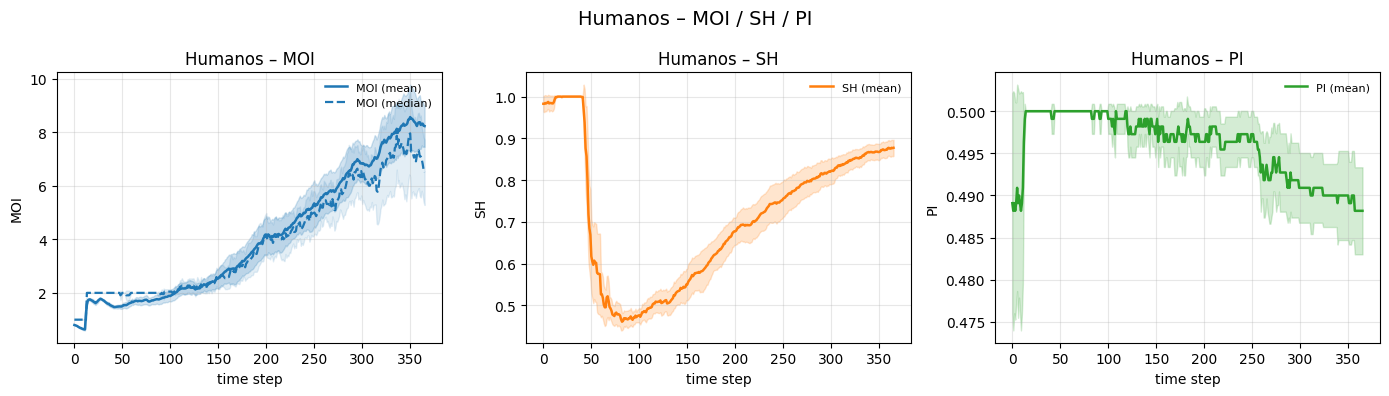

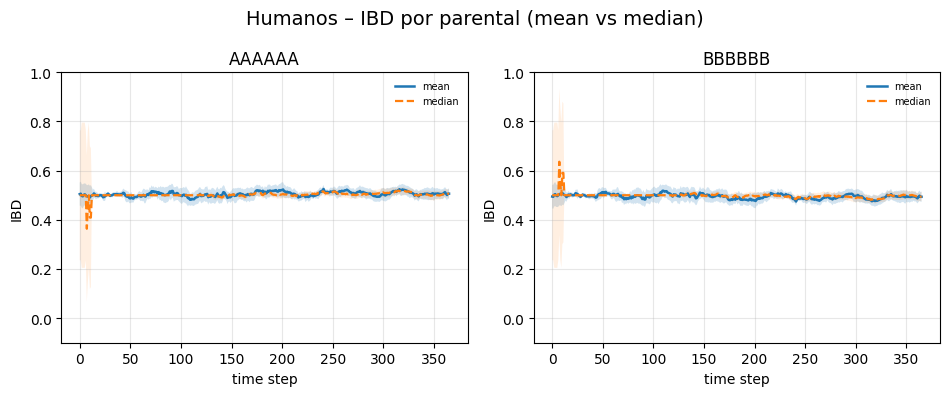

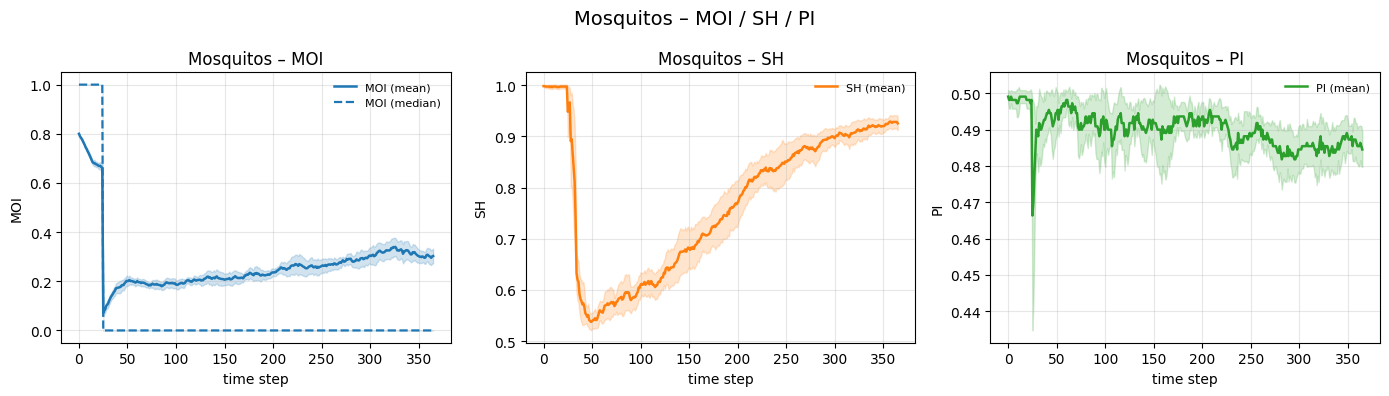

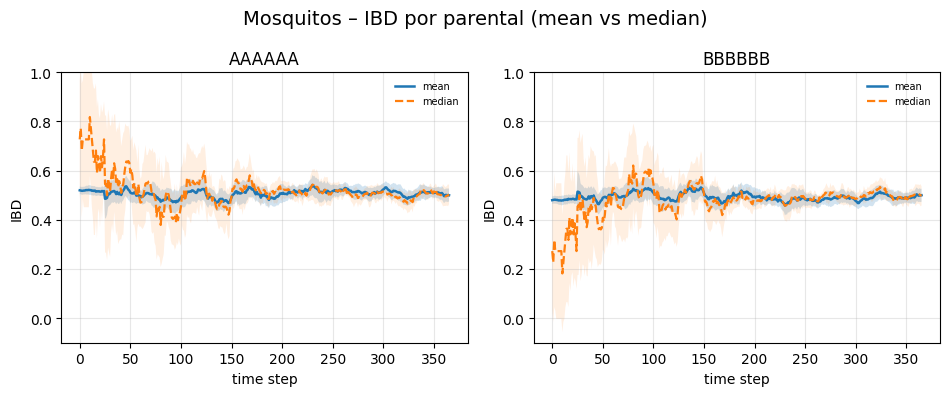

{'fig2_human': 'fig_2_num_genomes_2_bitting_rate_4_Humanos.jpg', 'fig3_human': 'fig_3_num_genomes_2_bitting_rate_4_Humanos.jpg', 'fig2_mosq': 'fig_2_num_genomes_2_bitting_rate_4_Mosquitos.jpg', 'fig3_mosq': 'fig_3_num_genomes_2_bitting_rate_4_Mosquitos.jpg'}


In [2]:
saved_paths = plot_indicadores_from_pkl("results/num_genomes_2_bitting_rate_4")
print(saved_paths)

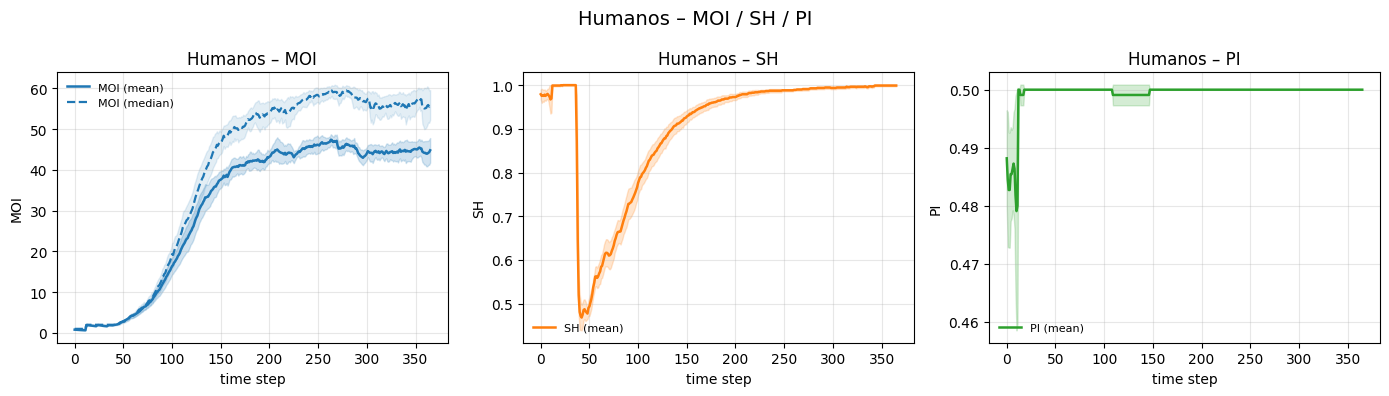

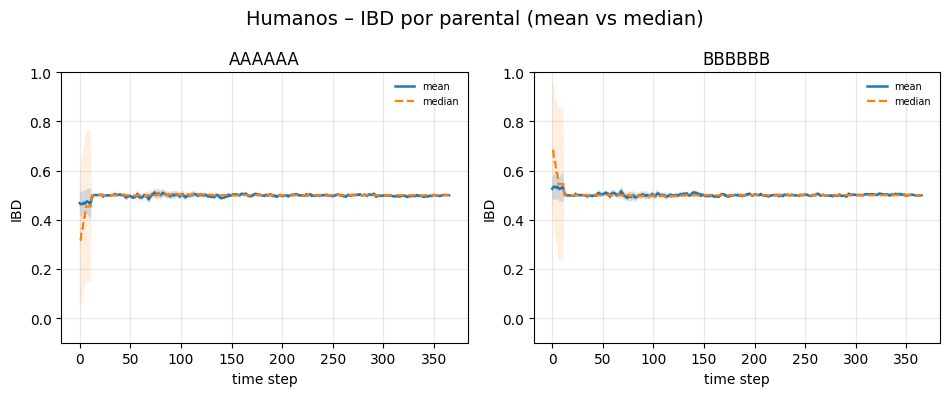

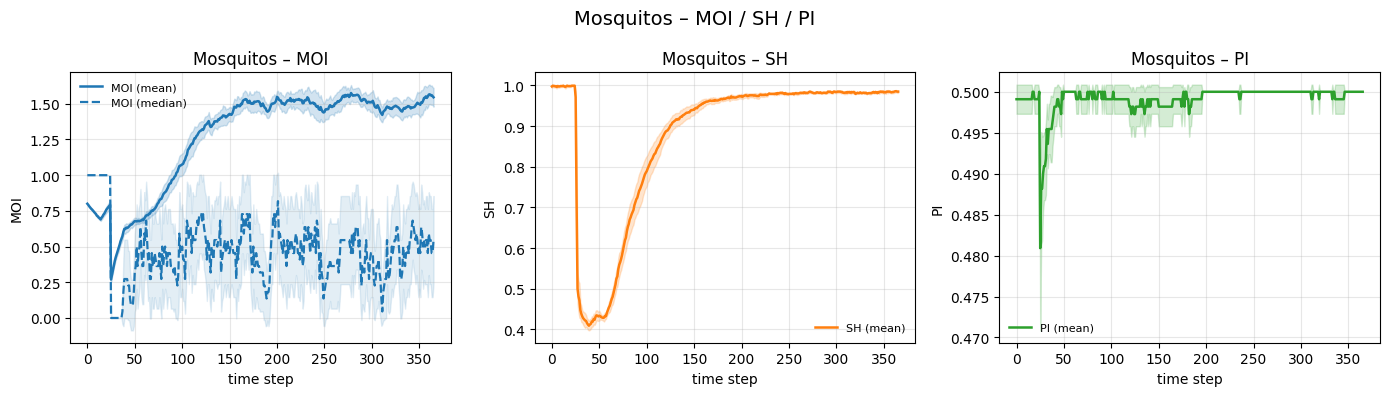

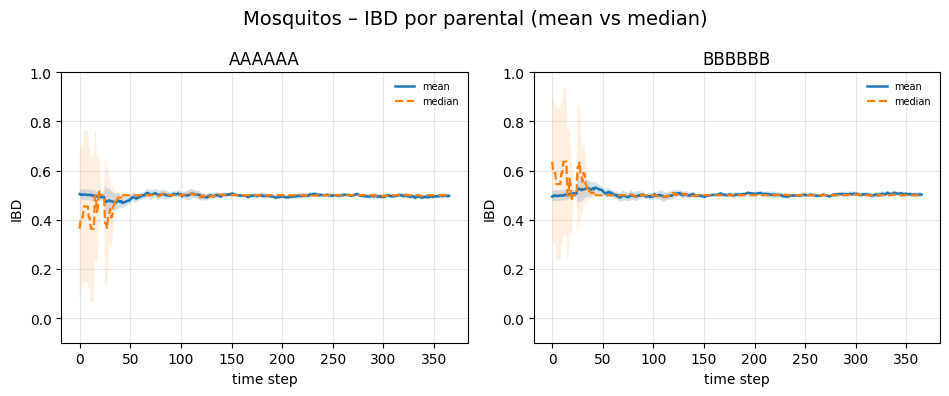

In [3]:
saved_paths = plot_indicadores_from_pkl("results/num_genomes_2_bitting_rate_40")


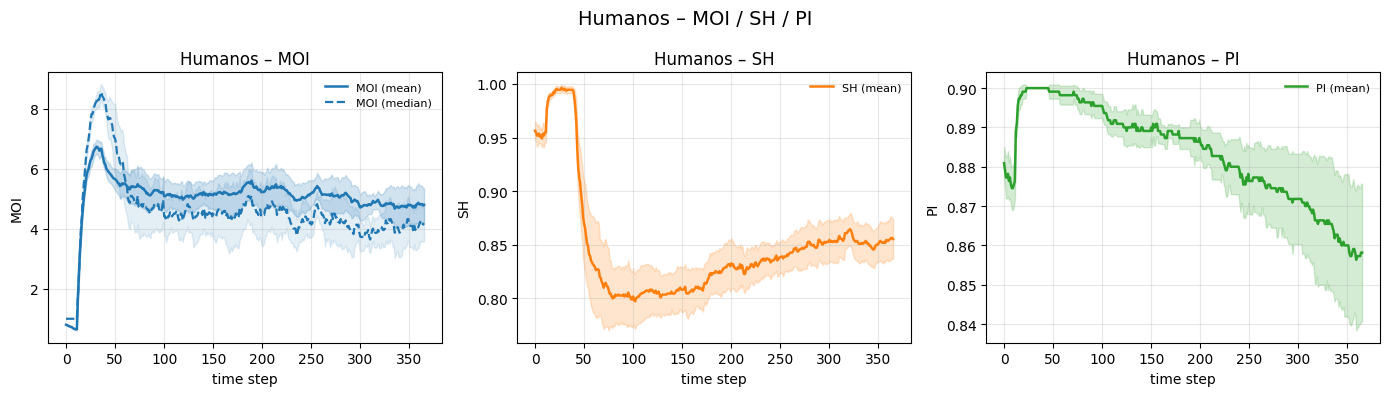

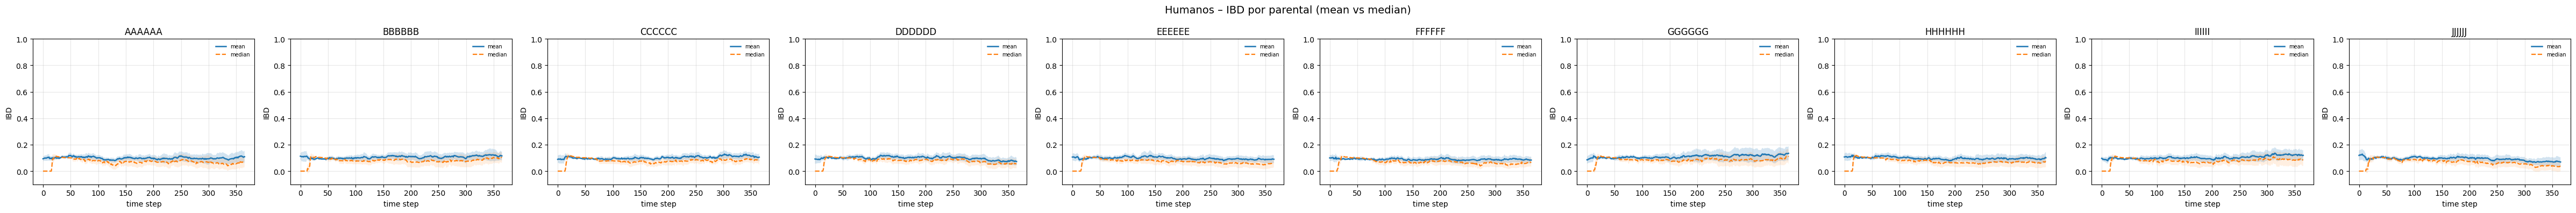

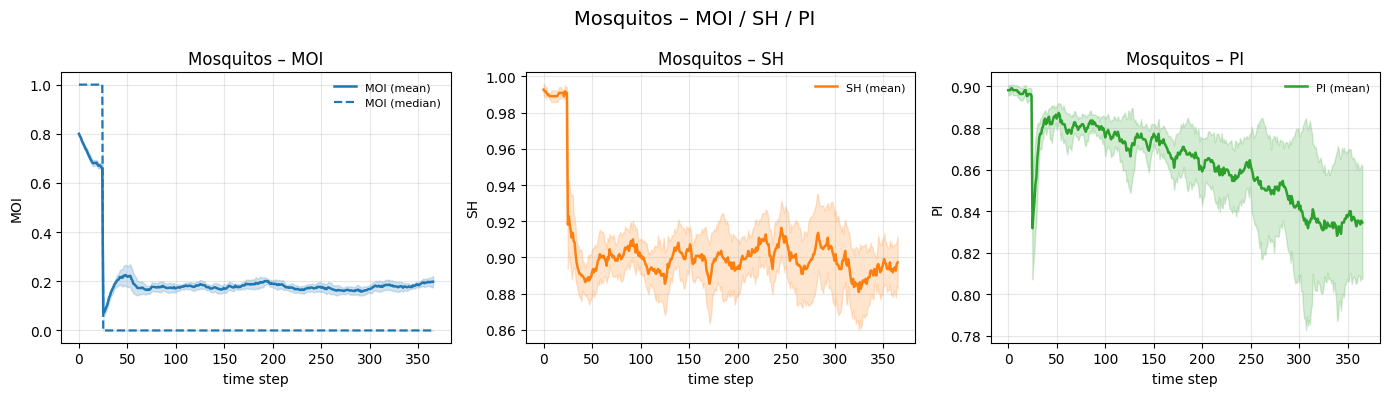

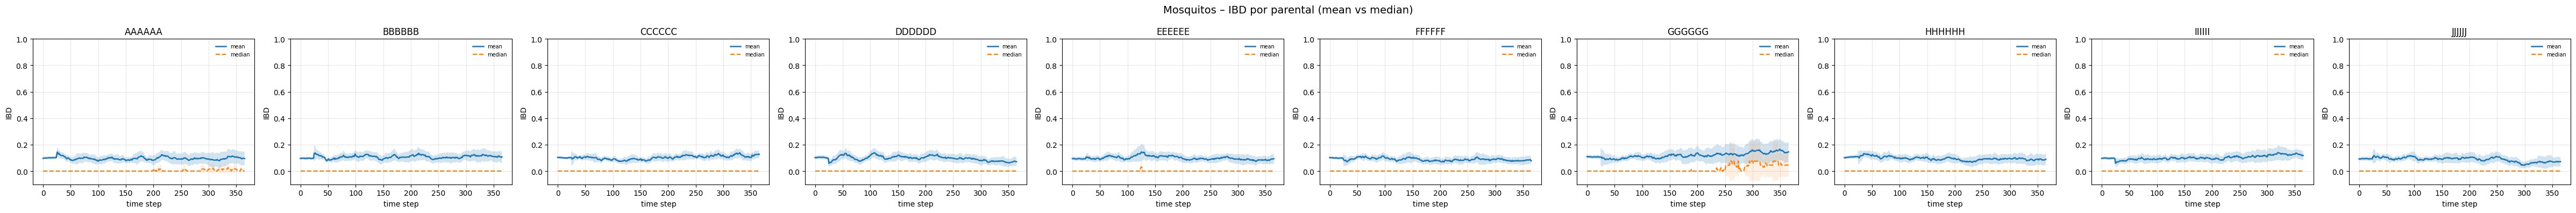

In [4]:
saved_paths = plot_indicadores_from_pkl("results/num_genomes_10_bitting_rate_4")

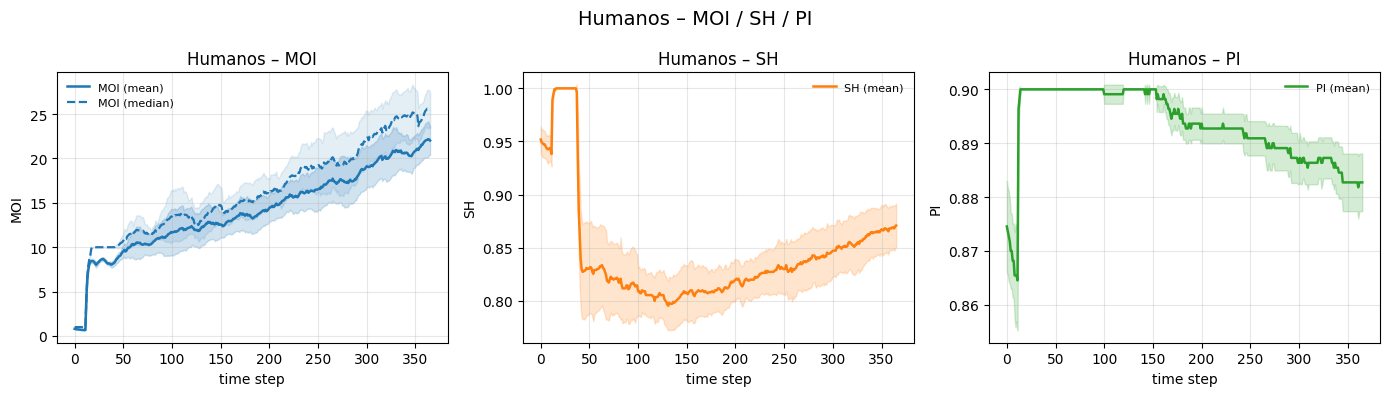

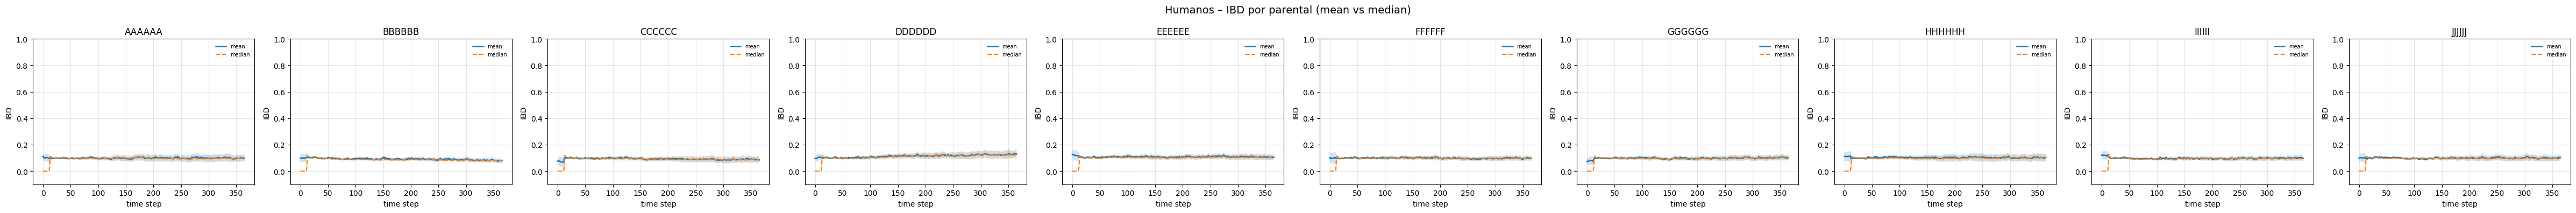

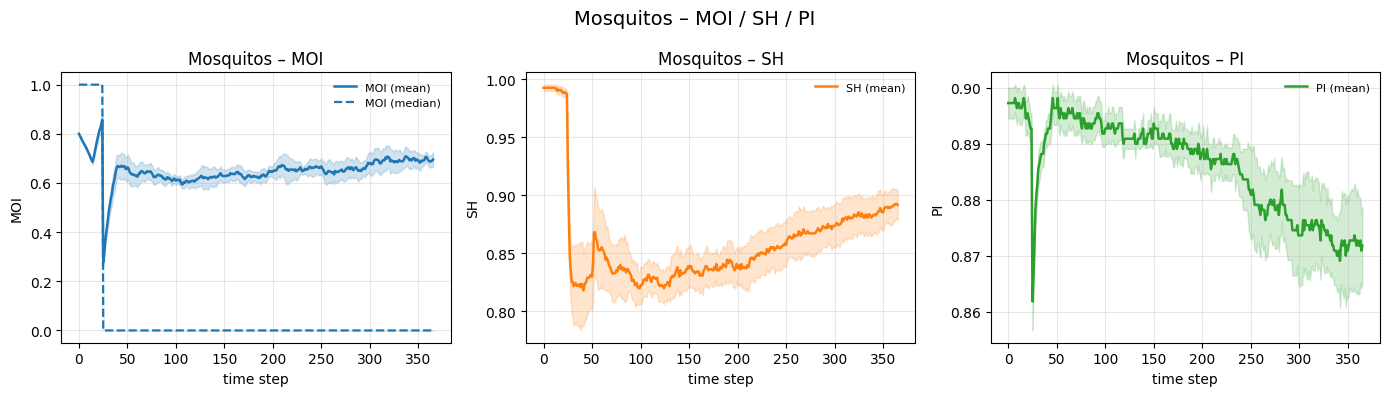

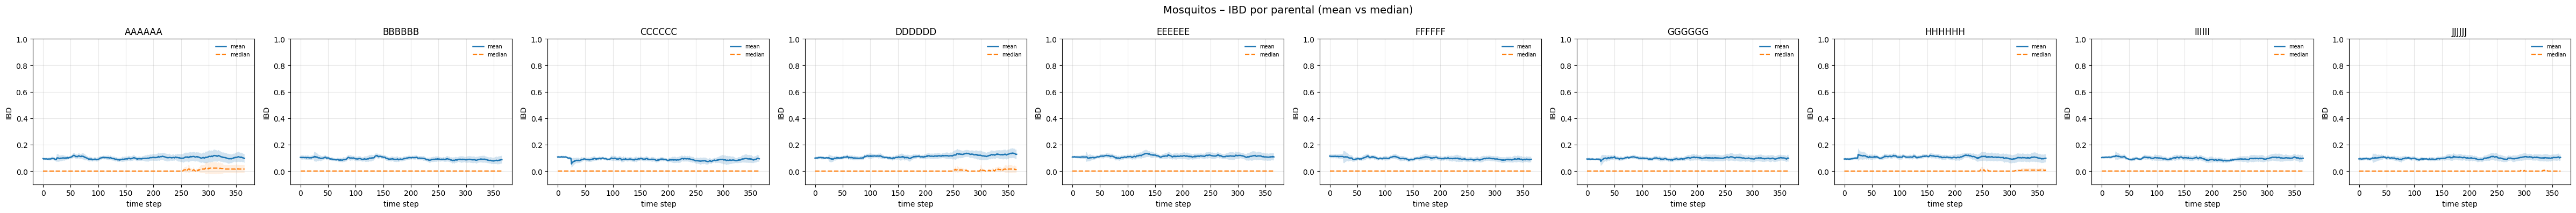

In [5]:
saved_paths = plot_indicadores_from_pkl("results/num_genomes_10_bitting_rate_40")
